In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("Pandas version:", pd.__version__)
print("✅ Environment is fully functional!")

Pandas version: 3.0.2
✅ Environment is fully functional!


In [ ]:
import pandas as pd

# Load the Excel file but specify the sheet name
# Usually the data sheet is named 'E Comm' or 'Data'
df = pd.read_excel('data.xlsx', sheet_name='E Comm')

# Save this one as your real CSV
df.to_csv('data.csv', index=False)

# Check the first few rows
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [13]:
df = pd.read_csv('data.csv')
df.head()
df.columns


Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='str')

In [14]:
# Check for missing values
print("--- Missing Values ---")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

--- Missing Values ---
CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

Duplicate rows: 0


In [15]:
# Create a copy to keep the original data safe
df_clean = df.copy()

# List of columns to fill with Median
cols_to_fix = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
               'OrderAmountHikeFromlastYear', 'CouponUsed', 
               'OrderCount', 'DaySinceLastOrder']

for col in cols_to_fix:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Verify that all zeros are gone
print("Remaining missing values:")
print(df_clean.isnull().sum().sum())

Remaining missing values:
0


In [16]:
# Automatically convert all text columns into numbers (0 and 1)
df_final = pd.get_dummies(df_clean, columns=['PreferredLoginDevice', 'PreferredPaymentMode', 
                                            'Gender', 'PreferedOrderCat', 'MaritalStatus'], 
                          drop_first=True)

print(f"New shape after encoding: {df_final.shape}")
df_final.head()

New shape after encoding: (5630, 31)


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,50001,1,4.0,3,6.0,3.0,3,2,9,1,...,False,False,False,False,True,False,False,False,False,True
1,50002,1,9.0,1,8.0,3.0,4,3,7,1,...,False,True,True,False,False,True,False,False,False,True
2,50003,1,9.0,1,30.0,2.0,4,3,6,1,...,False,False,True,False,False,True,False,False,False,True
3,50004,1,0.0,3,15.0,2.0,4,5,8,0,...,False,False,True,False,True,False,False,False,False,True
4,50005,1,0.0,1,12.0,3.0,3,5,3,0,...,False,False,True,False,False,True,False,False,False,True


In [17]:
# 'X' is the features, 'y' is the target
X = df_final.drop(['Churn', 'CustomerID'], axis=1)
y = df_final['Churn']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (4504, 29)
Testing set size: (1126, 29)


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [20]:
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Confusion Matrix ---
[[935   1]
 [ 18 172]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       936
           1       0.99      0.91      0.95       190

    accuracy                           0.98      1126
   macro avg       0.99      0.95      0.97      1126
weighted avg       0.98      0.98      0.98      1126



C:\Users\VARSHINI IYER\AppData\Local\Temp\ipykernel_20508\1679127954.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:10], y=feature_names[indices][:10], palette='magma')


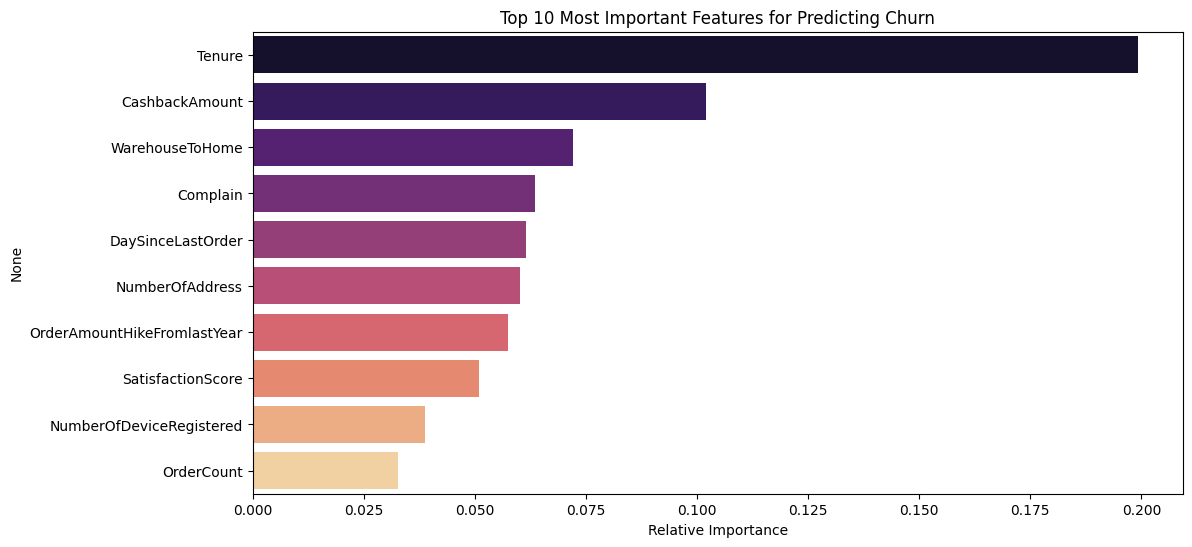

In [21]:
import numpy as np

# Get feature importances
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Plot the top 10 features
plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices][:10], y=feature_names[indices][:10], palette='magma')
plt.title('Top 10 Most Important Features for Predicting Churn')
plt.xlabel('Relative Importance')
plt.show()

In [22]:
pip install shap

  Using cached shap-0.51.0-cp312-cp312-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.51.0-cp312-cp312-win_amd64.whl (556 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
    --------------------------------------- 0.8/38.1 MB 3.1 MB/s eta 0:00:13
    --------------------------------------- 0.8/38.1 MB 3.1 MB/s eta 0:00:13
   - -------------------------------------- 1.0/38.1 MB 1.3 MB/s eta 0:00:29
   - -------------------------------------- 1.3/38.1 MB 1.3 MB/s eta 0:00:30
   -- ------------------------------------- 2.1/38.1 MB 1.7 MB/s eta 0:00:22
   --- ------------------------------------ 2.9/38.1 MB 2.0 MB/s eta 0:00:18
   --- ------------------------------------ 3.7/38.1 MB 2.2 MB/s eta 0:00:16
   ---- ----------------------------------- 4.7/38.1 MB 2.5 MB/s eta 0:00:14


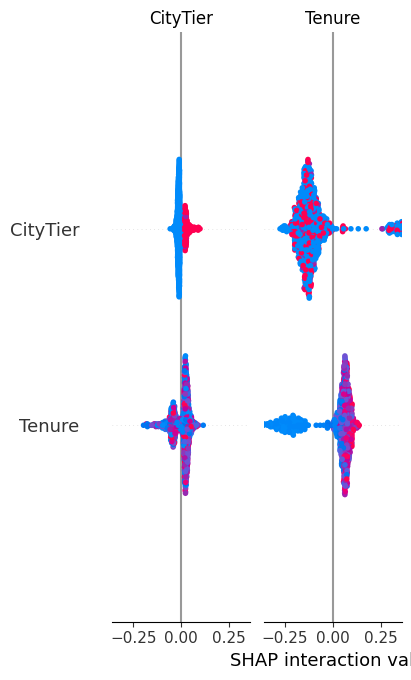

In [25]:
# 1. Force all data to be float64
X_train_float = X_train.astype(float)
X_test_float = X_test.astype(float)

# 2. Re-run SHAP with the forced types
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_float)

# 3. Check the structure of shap_values
# (For Random Forest, it's usually a list of two arrays: [stay_values, churn_values])
if isinstance(shap_values, list):
    # Use index 1 for the 'Churn' class
    shap.summary_plot(shap_values[1], X_test_float)
else:
    # If it's a single array (depending on SHAP version)
    shap.summary_plot(shap_values, X_test_float)

In [26]:
import joblib

# Save the model and the columns (so we know the order later)
model_data = {
    "model": model,
    "features": list(X.columns)
}

joblib.dump(model_data, 'churn_model.pkl')
print("✅ Model saved as 'churn_model.pkl'")

✅ Model saved as 'churn_model.pkl'


In [28]:
# Let's look at one specific customer from the test set who churned
sample_customer = X_test_float.iloc[0:1]
prediction = model.predict(sample_customer)
probability = model.predict_proba(sample_customer)

print(f"Customer Churn Prediction: {'Will Leave' if prediction[0] == 1 else 'Will Stay'}")
print(f"Probability of Churning: {probability[0][1]:.2%}")

Customer Churn Prediction: Will Stay
Probability of Churning: 1.00%


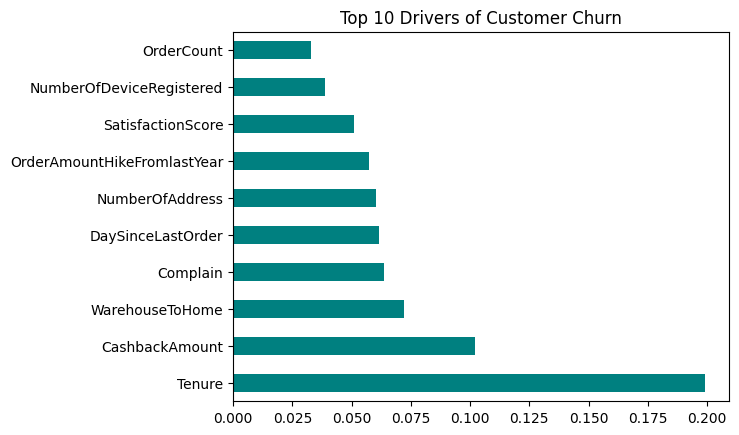

In [29]:
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top 10 Drivers of Customer Churn")
plt.show()